In [1]:
import sys
import os
from datetime import datetime

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

from scipy.linalg import sqrtm
from scipy.linalg import inv

from joblib import Parallel, delayed

sys.path.insert(0, '../')
from codes.Quantum import *

from codes.Quantum import *
from codes.CSPSA import CSPSA
from ClassicalShadows import EnchancedShadowTomography

In [2]:
Rho = None
enhanced_shadows = None


gains = [3, 0, 0.1, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False)


def complex2unitary( Z ):
    """
    Proyecta una matriz compleja arbitraria Z al grupo unitario U(4)
    mediante descomposición polar, U = Z (Z^dagger Z)^{-1/2}.
    """
    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )
    return Z


def random_unitary( dim, num=1 ):
    """
    Genera 'num' matrices unitarias aleatorias de dimensión 'dim'.
    """
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()


def maximally_entangled_state():
    """
    Estado singlete de dos qubits, (|01> - |10>)/sqrt(2), sin parámetro libre.
    """
    psi = np.array([0, 1, -1, 0]) / np.sqrt(2)
    return np.outer(psi, psi.conj())


def schmidt_state(a):
    """
    Estado puro de dos qubits en descomposición de Schmidt con parámetro
    a en [0, 0.5]. a = 0.5 recupera el estado maximamente entrelazado,
    a = 0 recupera el estado producto |00>.
    """
    psi = np.sqrt(1 - a) * np.array([1, 0, 0, 0]) \
        + np.sqrt(a) * np.array([0, 0, 0, 1])
    return np.outer(psi, psi.conj())


def werner_state(p):
    """
    Estado de Werner de dos qubits, mezcla convexa entre el estado singlete
    y el estado maximamente mixto, con parámetro de pureza p en [0, 1].
    p = 1 recupera el estado singlete puro, p = 0 el estado maximamente mixto.
    """
    rho_singlet = maximally_entangled_state()
    return p * rho_singlet + (1 - p) * np.eye(4) / 4


def build_network_state(rho_X, rho_Y, rho_Z):
    """
    Construye la matriz densidad conjunta de los seis qubits de la red
    triangular a partir de los estados de dos qubits (rho_X, rho_Y, rho_Z)
    distribuidos de forma independiente por las tres fuentes, reordenando
    los qubits para que cada detector reciba el par que le corresponde.
    """
    Rho = np.kron(np.kron(rho_X, rho_Y), rho_Z)
    permutation = [5, 0, 2, 1, 4, 3]
    order = permutation + [6 + q for q in permutation]
    Rho = Rho.reshape(12 * [2]).transpose(order).reshape(64, 64)
    return Rho


def create_shadow(Rho, N):
    """
    Entrena una sombra clasica de tamaño N a partir del estado Rho, y
    construye a partir de ella la reconstruccion Rho_hat que se usa como
    estado de referencia sigma en el estimador con variable de control.
    """
    shadow = EnchancedShadowTomography(6, N)
    shadow.train_shadows(Rho)
    Rho_hat = shadow.estimate_density_matrix()
    shadow.enhance_shadow(Rho_hat)
    return shadow, Rho_hat


def out_fun( Z, Rho=Rho ):
    """
    Evalua el funcional wagon-wheel de forma exacta, tal como se calcula
    en cspsa_triangle_shadows.ipynb, sin ninguna modificación en el cálculo.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Measures = triple_kron( Z[0], Z[1], Z[2] ) 
    probs  = np.sum( Measures.conj() * ( Rho @ Measures ), 
                        axis=0 ).reshape(6*[2]).real 
    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )
    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun( Z, enhanced_shadows=enhanced_shadows ):
    """
    Evalua el funcional wagon-wheel estimando cada termino con Classical
    Shadows en su version estandar (sin variable de control). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality 


def obj_fun_enhanced( Z, enhanced_shadows=enhanced_shadows):
    """
    Igual a obj_fun, pero estimando cada termino con la correccion de
    variable de control (estimate_global_observable_enhanced). Cálculo
    idéntico al de cspsa_triangle_shadows.ipynb.
    """
    Z  = np.array(Z)
    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable_enhanced( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable_enhanced( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)
    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality

from joblib import Parallel, delayed

def run_simulation(Rho, N_rep, max_iter, N_shadow, nombre_archivo,
                    carpeta=".", n_jobs=-1):
    """
    Corre el protocolo completo de optimizacion (Tomo, Shadow, EnhShadow)
    sobre el estado Rho entregado, durante N_rep repeticiones independientes
    de max_iter iteraciones cada una, reentrenando una sombra de N_shadow
    mediciones en cada repeticion. Las repeticiones se paralelizan con
    joblib, y cada una reinicializa su semilla aleatoria para asegurar
    independencia entre procesos.

    Guarda en carpeta/nombre_archivo, imitando el formato de
    Tesis_Schmidt.ipynb, el arreglo crudo de cada nivel de evaluacion
    (Out1, Out2, Out3) junto con su mean, median, q1 y q3 por iteracion,
    mas metadatos (N_rep, max_iter, N_shadow).
    """
    def run_one(idx):
        np.random.seed()
        print(idx)

        enhanced_shadows, Rho_hat = create_shadow(Rho, N_shadow)

        obj_fun_tomo = lambda Z: out_fun(Z, Rho_hat)
        obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
        obj_fun_enha = lambda Z: obj_fun_enhanced(Z, enhanced_shadows)

        Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])

        results1 = cspsa.minimize(obj_fun_tomo, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_tomo)
        results2 = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_shad)
        results3 = cspsa.minimize(obj_fun_enha, Z_in3, max_iter,
                                   postprocessing=complex2unitary,
                                   output_function=obj_fun_enha)

        return results1.fun, results2.fun, results3.fun

    resultados = Parallel(n_jobs=n_jobs)(
        delayed(run_one)(idx) for idx in range(N_rep)
    )
    resultados = np.array(resultados)

    Out1 = resultados[:, 0]
    Out2 = resultados[:, 1]
    Out3 = resultados[:, 2]

    os.makedirs(carpeta, exist_ok=True)
    ruta = os.path.join(carpeta, nombre_archivo)

    np.savez(ruta,
             Out1=Out1, Out2=Out2, Out3=Out3,
             mean1=Out1.mean(axis=0), median1=np.median(Out1, axis=0),
             q1_1=np.percentile(Out1, 25, axis=0), q3_1=np.percentile(Out1, 75, axis=0),
             mean2=Out2.mean(axis=0), median2=np.median(Out2, axis=0),
             q1_2=np.percentile(Out2, 25, axis=0), q3_2=np.percentile(Out2, 75, axis=0),
             mean3=Out3.mean(axis=0), median3=np.median(Out3, axis=0),
             q1_3=np.percentile(Out3, 25, axis=0), q3_3=np.percentile(Out3, 75, axis=0),
             N_rep=N_rep, max_iter=max_iter, N_shadow=N_shadow)

    print(f"  Guardado: {ruta}")

    return Out1, Out2, Out3


def cargar_npz(carpeta, nombre_archivo):
    """
    Carga el archivo .npz correspondiente a una simulacion, ubicado en
    carpeta/nombre_archivo.
    """
    return np.load(os.path.join(carpeta, nombre_archivo))

## Simulación 02_03 — Evaluación exacta y Shadow, estados de Schmidt (actualizada)

**Carpeta de datos:** `Simulacion_02`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Descomposición de Schmidt, $\sqrt{1-a}\,\lvert 00\rangle+\sqrt{a}\,\lvert 11\rangle$, mismo $a$ en las tres fuentes |
| $N_{\rm sh}$ (mediciones por sombra) | $\{10^5,\ 10^6\}$, sombra reentrenada en cada repetición |
| `N_rep` | 100 (por cada uno de los dos bloques) |
| $N_{\rm it}$ (iteraciones de CSPSA) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |
| Bloques de evaluación | Exacta, y Mixta+Shadow sobre la misma trayectoria |

**Descripción:** actualiza la versión anterior de Sim02_03, corrigiendo
el diseño para que la comparación entre la evaluación exacta y la
estimación por sombra se haga sobre el mismo punto de la optimización,
no sobre dos optimizaciones independientes. Para cada valor de $a$ y de
$N_{\rm sh}$ se corren dos bloques de `N_rep` repeticiones. El primero,
guiado y evaluado enteramente por `out_fun` (evaluación exacta,
`Out_ex`), independiente de todo lo demás. El segundo, una única
optimización por repetición, guiada por `obj_fun` (la sombra decide
cada paso de CSPSA), pero en cada paso se registran simultáneamente dos
valores del mismo punto $Z$ alcanzado, el valor exacto de ese punto
(`Out_mix`, vía `out_fun`) y el valor estimado por sombra de ese mismo
punto (`Out_sh`, vía `obj_fun`), sin que la evaluación exacta influya
en el gradiente ni en las actualizaciones de CSPSA. En total se corren
$2\times N_{\rm rep}$ optimizaciones por cada combinación de $a$ y
$N_{\rm sh}$, no $3\times N_{\rm rep}$.

**Sim02_03_01:** $a \in \{0.00,\ 0.25,\ 0.50\}$, cada uno con
$N_{\rm sh}\in\{10^5,10^6\}$.

**Sim02_03_02:** $a \in \{0.30,\ 0.35,\ 0.40,\ 0.45,\ 0.50\}$, cada uno
con $N_{\rm sh}\in\{10^5,10^6\}$.

**Archivos generados:** mismos nombres que antes,
`Simulacion_02/Sim02_03_01_a{valor}_N1e{exp}.npz` y
`Simulacion_02/Sim02_03_02_a{valor}_N1e{exp}.npz`, pero ahora cada
archivo contiene `Out_ex`, `Out_mix` y `Out_sh` (de tamaño `N_rep` x
$N_{\rm it}$ cada uno), junto con `mean`, `median`, `q1` y `q3` por
iteración para los tres (`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, y lo
mismo con sufijos `_mix` y `_sh`), en lugar de solo `Out_ex`/`Out_sh`
como en la versión anterior.

## Función `run_triple_schmidt_grid`

Para cada combinación de $a$ y $N_{\rm sh}$, corre dos bloques de
`N_rep` repeticiones. El primero, guiado y evaluado por `out_fun`
(exacta completa, `Out_ex`). El segundo, una única optimización por
repetición guiada por `obj_fun`, que registra simultáneamente en cada
paso la evaluación exacta (`Out_mix`) y la evaluación por sombra
(`Out_sh`) del mismo punto alcanzado.

In [10]:
def run_triple_schmidt_grid(valores_a, valores_N_sh, prefijo, carpeta="Simulacion_02",
                             N_rep=100, max_iter=1000, n_jobs=-6):
    """
    Para cada combinacion de a en valores_a y N_sh en valores_N_sh,
    construye el estado de Schmidt correspondiente y corre dos bloques
    de N_rep repeticiones:
      - Out_ex: guiada y evaluada por out_fun (exacta completa).
      - Out_mix y Out_sh: obtenidas sobre la misma trayectoria guiada
        por obj_fun. Out_mix registra la evaluacion exacta y Out_sh
        registra la evaluacion mediante Classical Shadows.
    """
    resultados = {}
    for a in valores_a:
        Rho_sch = build_network_state(*3 * [schmidt_state(a)])

        for N_sh in valores_N_sh:
            exponente = round(np.log10(N_sh))
            print(f"=== {prefijo}, a = {a:.2f}, N_sh = 1e{exponente} ===")

            def run_one_exacto(idx):
                np.random.seed()
                obj_fun_exacto = lambda Z: out_fun(Z, Rho_sch)
                Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
                results = cspsa.minimize(obj_fun_exacto, Z_in3, max_iter,
                                          postprocessing=complex2unitary,
                                          output_function=obj_fun_exacto)
                return results.fun

            def run_one_shadow(idx):
                np.random.seed()
                enhanced_shadows, Rho_hat = create_shadow(Rho_sch, N_sh)
                obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
                obj_fun_exacto = lambda Z: out_fun(Z, Rho_sch)

                def output_dual(Z):
                    return obj_fun_exacto(Z), obj_fun_shad(Z)

                Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
                results = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                          postprocessing=complex2unitary,
                                          output_function=output_dual)
                return np.asarray(results.fun)

            Out_ex = np.array(Parallel(n_jobs=n_jobs)(
                delayed(run_one_exacto)(idx) for idx in range(N_rep)
            ))

            Out_dual = np.array(Parallel(n_jobs=n_jobs)(
                delayed(run_one_shadow)(idx) for idx in range(N_rep)
            ))

            Out_mix = Out_dual[:, :, 0]
            Out_sh = Out_dual[:, :, 1]

            os.makedirs(carpeta, exist_ok=True)
            nombre_archivo = f"{prefijo}_a{a:.2f}_N1e{exponente}.npz"
            ruta = os.path.join(carpeta, nombre_archivo)

            np.savez(ruta,
                     Out_ex=Out_ex, Out_mix=Out_mix, Out_sh=Out_sh,
                     mean_ex=Out_ex.mean(axis=0), median_ex=np.median(Out_ex, axis=0),
                     q1_ex=np.percentile(Out_ex, 25, axis=0), q3_ex=np.percentile(Out_ex, 75, axis=0),
                     mean_mix=Out_mix.mean(axis=0), median_mix=np.median(Out_mix, axis=0),
                     q1_mix=np.percentile(Out_mix, 25, axis=0), q3_mix=np.percentile(Out_mix, 75, axis=0),
                     mean_sh=Out_sh.mean(axis=0), median_sh=np.median(Out_sh, axis=0),
                     q1_sh=np.percentile(Out_sh, 25, axis=0), q3_sh=np.percentile(Out_sh, 75, axis=0),
                     N_rep=N_rep, N_it=max_iter, N_sh=N_sh, a=a)

            print(f"  Guardado: {ruta}")
            resultados[(a, N_sh)] = (Out_ex, Out_mix, Out_sh)

    return resultados

## Simulación 02_03 — Ejecución (actualizada)

Corre las dos grillas de Schmidt con evaluación exacta y Mixta+Shadow
sobre la misma trayectoria, cada una combinada con
$N_{\rm sh}\in\{10^5,10^6\}$, usando `run_triple_schmidt_grid`.

In [11]:
valores_sim02_03_01 = [0.00, 0.25, 0.50]
valores_sim02_03_02 = [0.30, 0.35, 0.40, 0.45, 0.50]
valores_N_sh = [1e5, 1e6]

resultados_sim02_03_01 = run_triple_schmidt_grid(
    valores_sim02_03_01, valores_N_sh, "Sim02_03_01", carpeta="Simulacion_02"
)
resultados_sim02_03_02 = run_triple_schmidt_grid(
    valores_sim02_03_02, valores_N_sh, "Sim02_03_02", carpeta="Simulacion_02"
)

=== Sim02_03_01, a = 0.00, N_sh = 1e5 ===


KeyboardInterrupt: 

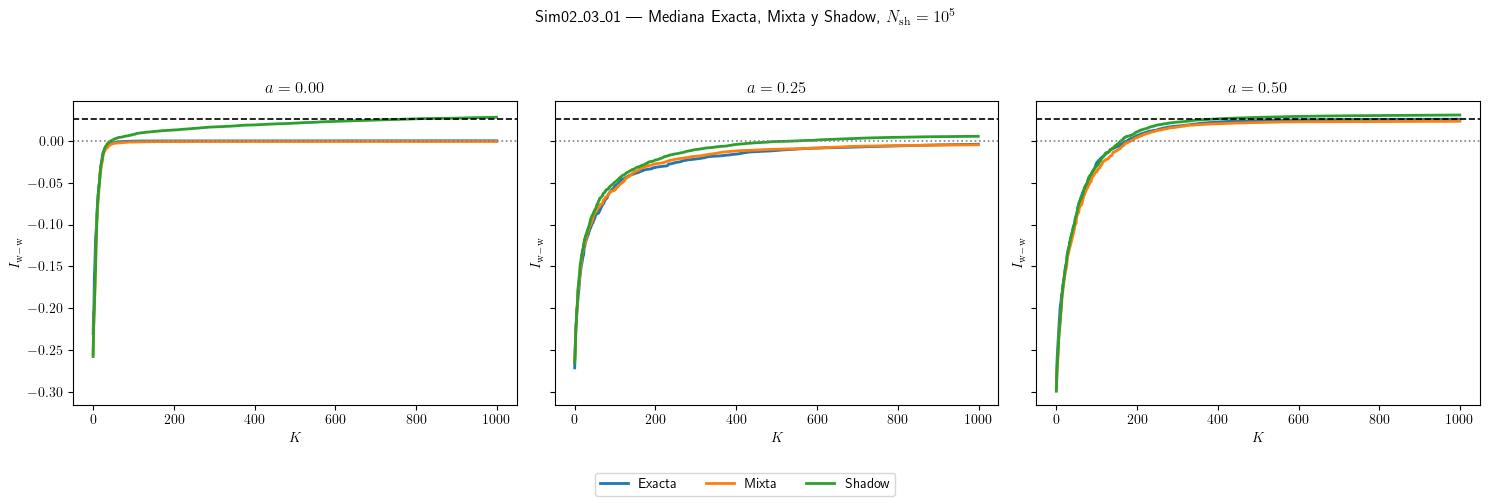

In [13]:
valor_cuantico = (np.sqrt(2) - 1) / 16
valores_sim02_03_01 = [0.00, 0.25, 0.50]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_01):
    ruta = f"Simulacion_02/Sim02_03_01_a{a:.2f}_N1e5.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mixta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$a={a:.2f}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim02\_03\_01 --- Mediana Exacta, Mixta y Shadow, $N_{\rm sh}=10^5$")
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
fig.savefig("Simulacion_02/Sim02_03_01_N1e5.pdf")
plt.show()

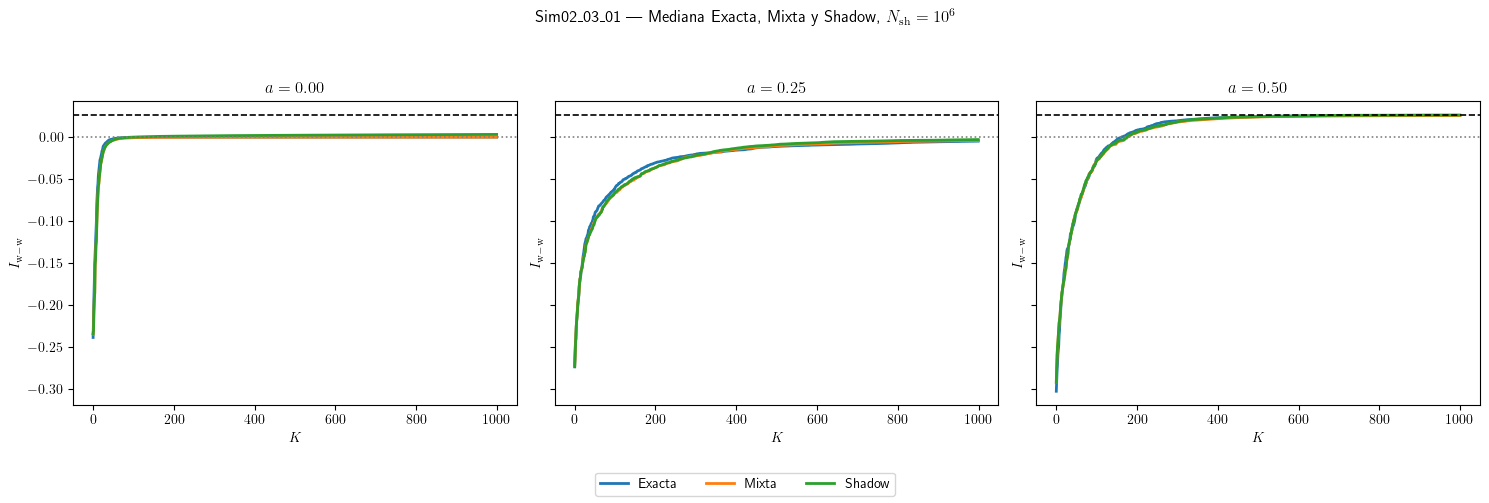

In [14]:
valor_cuantico = (np.sqrt(2) - 1) / 16
valores_sim02_03_01 = [0.00, 0.25, 0.50]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_01):
    ruta = f"Simulacion_02/Sim02_03_01_a{a:.2f}_N1e6.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mixta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$a={a:.2f}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim02\_03\_01 --- Mediana Exacta, Mixta y Shadow, $N_{\rm sh}=10^6$")
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
fig.savefig("Simulacion_02/Sim02_03_01_N1e6.pdf")
plt.show()

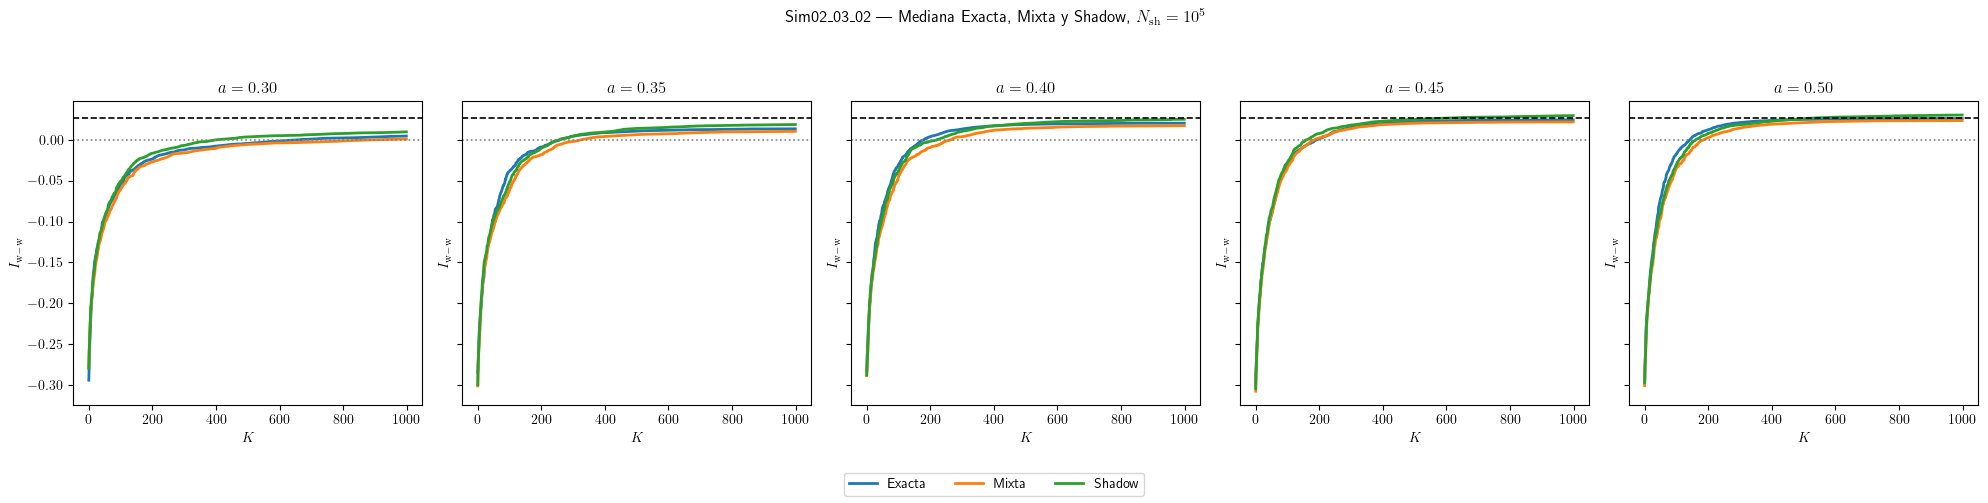

In [15]:
valor_cuantico = (np.sqrt(2) - 1) / 16
valores_sim02_03_02 = [0.30, 0.35, 0.40, 0.45, 0.50]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_02):
    ruta = f"Simulacion_02/Sim02_03_02_a{a:.2f}_N1e5.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mixta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$a={a:.2f}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim02\_03\_02 --- Mediana Exacta, Mixta y Shadow, $N_{\rm sh}=10^5$")
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
fig.savefig("Simulacion_02/Sim02_03_02_N1e5.pdf")
plt.show()

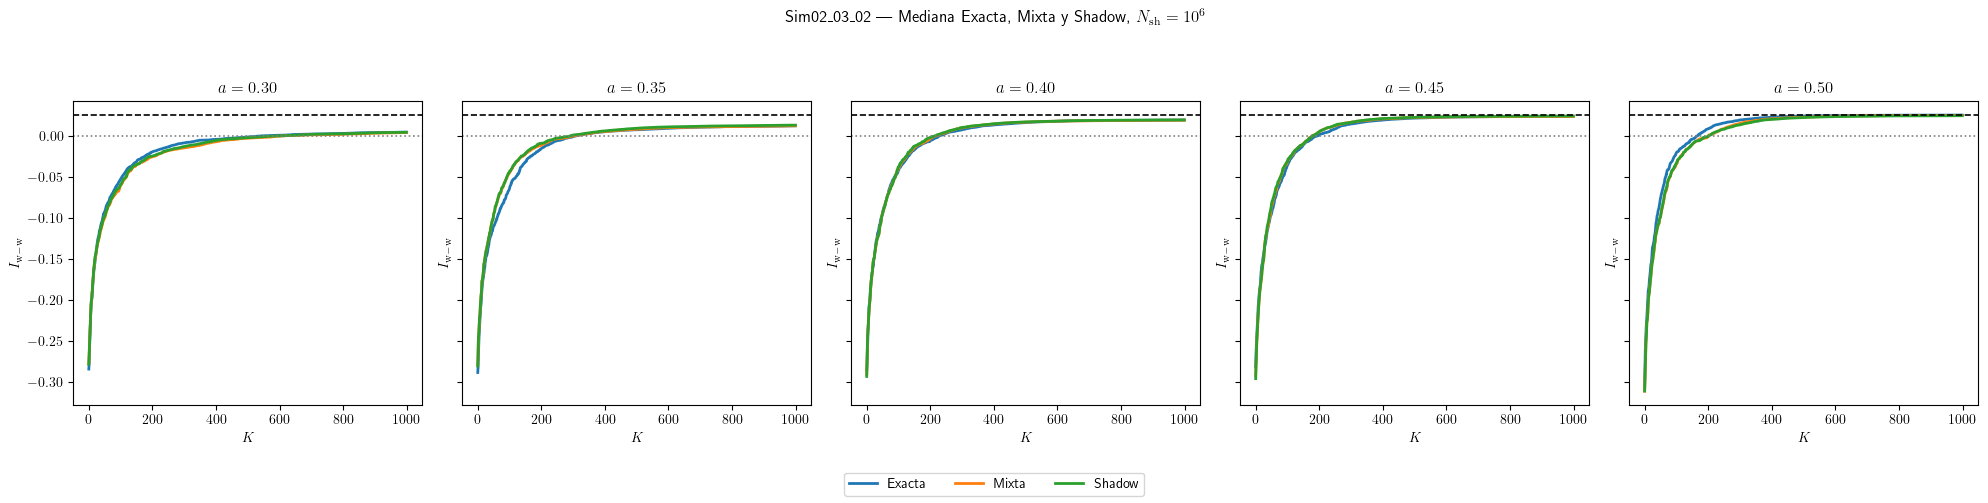

In [16]:
valor_cuantico = (np.sqrt(2) - 1) / 16
valores_sim02_03_02 = [0.30, 0.35, 0.40, 0.45, 0.50]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_02):
    ruta = f"Simulacion_02/Sim02_03_02_a{a:.2f}_N1e6.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data['median_ex']))

    ax.plot(it, Data['median_ex'], linewidth=2, label="Exacta")
    ax.plot(it, Data['median_mix'], linewidth=2, label="Mixta")
    ax.plot(it, Data['median_sh'], linewidth=2, label="Shadow")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1.2)
    ax.axhline(valor_cuantico, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(rf"$a={a:.2f}$")
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$I_{\rm w-w}$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
fig.suptitle(r"Sim02\_03\_02 --- Mediana Exacta, Mixta y Shadow, $N_{\rm sh}=10^6$")
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
fig.savefig("Simulacion_02/Sim02_03_02_N1e6.pdf")
plt.show()

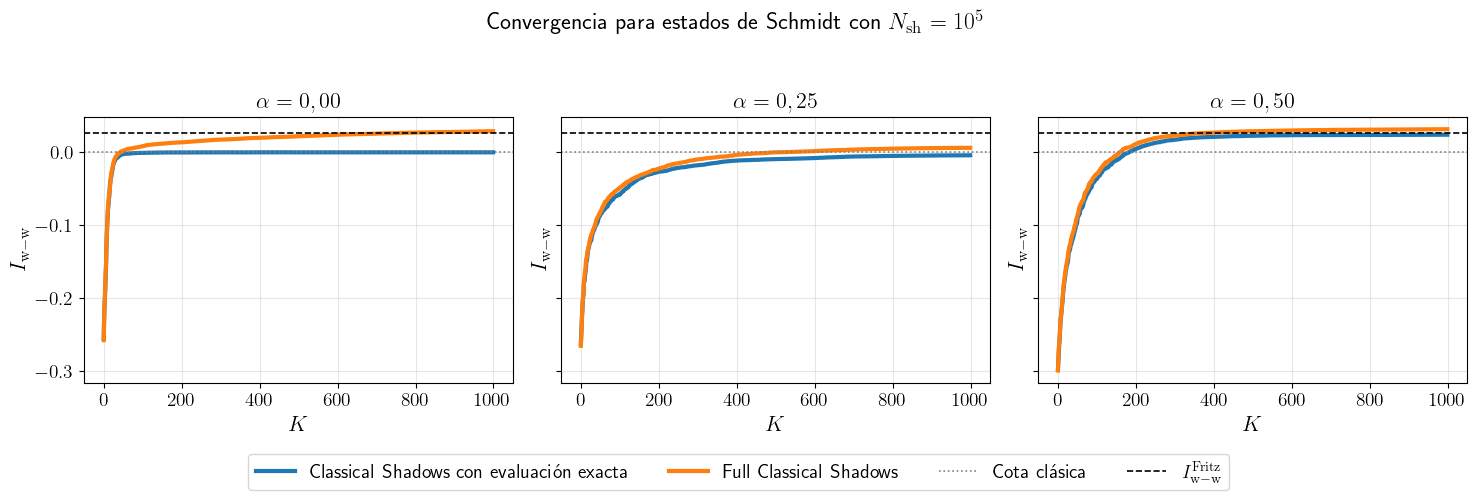

In [3]:
I_fritz = (np.sqrt(2) - 1) / 16

FS_TITLE = 16
FS_LABEL = 16
FS_TICKS = 14
FS_LEGEND = 14
FS_SUPTITLE = 17

valores_sim02_03_01 = [0.00, 0.25, 0.50]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_01):
    ruta = f"Simulacion_02/Sim02_03_01_a{a:.2f}_N1e5.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data["median_mix"]))
    a_texto = f"{a:.2f}".replace(".", ",")

    ax.plot(it, Data["median_mix"], linewidth=3, label="Classical Shadows con evaluación exacta")
    ax.plot(it, Data["median_sh"], linewidth=3, label="Full Classical Shadows")

    ax.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
    ax.axhline(I_fritz, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")

    ax.set_title(rf"$\alpha={a_texto}$", fontsize=FS_TITLE)
    ax.set_xlabel(r"$K$", fontsize=FS_LABEL)
    ax.set_ylabel(r"$I_{\rm w-w}$", fontsize=FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICKS)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=FS_LEGEND)

fig.suptitle(r"Convergencia para estados de Schmidt con $N_{\rm sh}=10^5$", fontsize=FS_SUPTITLE)
fig.tight_layout(rect=[0, 0.10, 1, 0.92])

fig.savefig("Simulacion_02/Sim02_03_01_N1e5_new.pdf")
plt.show()

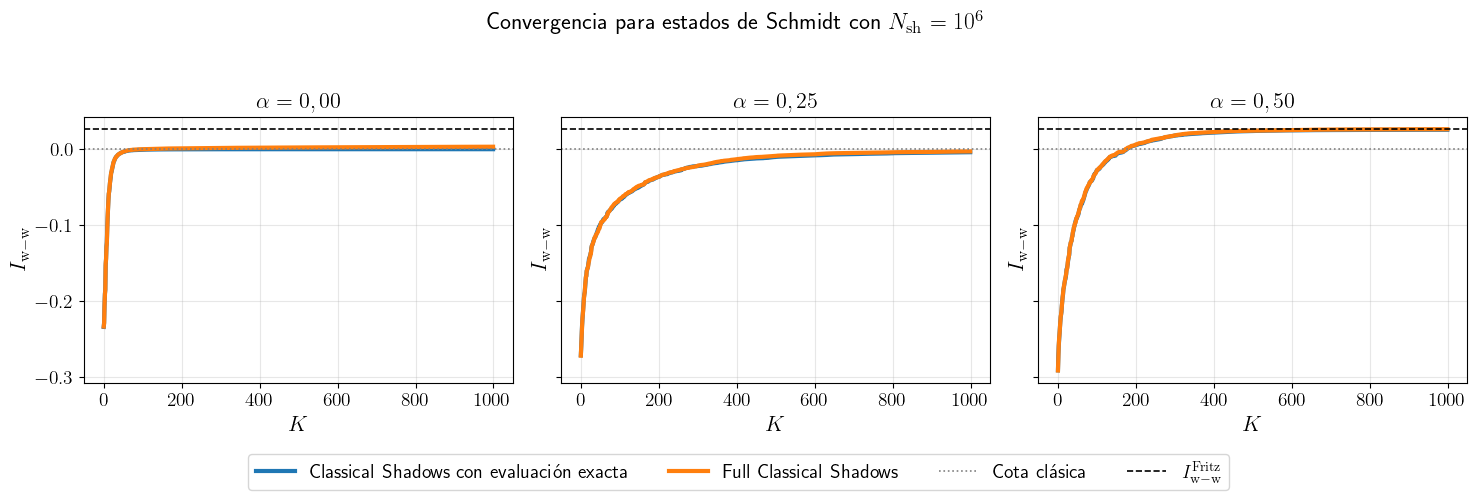

In [5]:
I_fritz = (np.sqrt(2) - 1) / 16

FS_TITLE = 16
FS_LABEL = 16
FS_TICKS = 14
FS_LEGEND = 14
FS_SUPTITLE = 17

valores_sim02_03_01 = [0.00, 0.25, 0.50]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, a in zip(axes, valores_sim02_03_01):
    ruta = f"Simulacion_02/Sim02_03_01_a{a:.2f}_N1e6.npz"
    Data = np.load(ruta)
    it = np.arange(len(Data["median_mix"]))
    a_texto = f"{a:.2f}".replace(".", ",")

    ax.plot(it, Data["median_mix"], linewidth=3, label="Classical Shadows con evaluación exacta")
    ax.plot(it, Data["median_sh"], linewidth=3, label="Full Classical Shadows")

    ax.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
    ax.axhline(I_fritz, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")

    ax.set_title(rf"$\alpha={a_texto}$", fontsize=FS_TITLE)
    ax.set_xlabel(r"$K$", fontsize=FS_LABEL)
    ax.set_ylabel(r"$I_{\rm w-w}$", fontsize=FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICKS)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=FS_LEGEND)

fig.suptitle(r"Convergencia para estados de Schmidt con $N_{\rm sh}=10^6$", fontsize=FS_SUPTITLE)
fig.tight_layout(rect=[0, 0.10, 1, 0.92])

fig.savefig("Simulacion_02/Sim02_03_01_N1e6_new.pdf")
plt.show()

## Simulación 03_03 — Evaluación exacta y Shadow, estados de Werner (actualizada)

**Carpeta de datos:** `Simulacion_03`

**Parámetros:**

| Parámetro | Valor |
|---|---|
| Estado (tres fuentes) | Werner, $p\,\lvert\psi^-\rangle\langle\psi^-\rvert+(1-p)\,\mathbb{I}_4/4$, mismo $p$ en las tres fuentes |
| $N_{\rm sh}$ (mediciones por sombra) | $\{10^5,\ 10^6\}$, sombra reentrenada en cada repetición |
| `N_rep` | 100 (por cada uno de los dos bloques) |
| $N_{\rm it}$ (iteraciones de CSPSA) | 1000 |
| `gains` | `[3, 0, 0.1, 0.602, 0.101]` |
| Optimizador | CSPSA (`minimize=False`, maximización) |
| Bloques de evaluación | Exacta, y Mixta+Shadow sobre la misma trayectoria |

**Descripción:** actualiza la versión anterior de Sim03_03, análoga a
la corrección aplicada a Sim02_03, para que la comparación entre la
evaluación exacta y la estimación por sombra se haga sobre el mismo
punto de la optimización, no sobre dos optimizaciones independientes.
Para cada valor de $p$ y de $N_{\rm sh}$ se corren dos bloques de
`N_rep` repeticiones. El primero, guiado y evaluado enteramente por
`out_fun` (evaluación exacta, `Out_ex`), independiente de todo lo
demás. El segundo, una única optimización por repetición, guiada por
`obj_fun` (la sombra decide cada paso de CSPSA), registrando
simultáneamente en cada paso el valor exacto del mismo punto $Z$
(`Out_mix`, vía `out_fun`) y el valor estimado por sombra de ese mismo
punto (`Out_sh`, vía `obj_fun`), sin que la evaluación exacta influya
en el gradiente ni en las actualizaciones de CSPSA. En total se corren
$2\times N_{\rm rep}$ optimizaciones por cada combinación de $p$ y
$N_{\rm sh}$, no $3\times N_{\rm rep}$.

**Sim03_03_01:** $p \in \{0.0,\ 0.2,\ 0.4,\ 0.6,\ 0.8,\ 1.0\}$, cada uno
con $N_{\rm sh}\in\{10^5,10^6\}$.

**Sim03_03_02:** $p \in \{0.90,\ 0.92,\ 0.94,\ 0.96,\ 0.98,\ 1.00\}$,
cada uno con $N_{\rm sh}\in\{10^5,10^6\}$.

**Archivos generados:** mismos nombres que antes,
`Simulacion_03/Sim03_03_01_p{valor}_N1e{exp}.npz` y
`Simulacion_03/Sim03_03_02_p{valor}_N1e{exp}.npz`, pero ahora cada
archivo contiene `Out_ex`, `Out_mix` y `Out_sh` (de tamaño `N_rep` x
$N_{\rm it}$ cada uno), junto con `mean`, `median`, `q1` y `q3` por
iteración para los tres (`mean_ex`/`median_ex`/`q1_ex`/`q3_ex`, y lo
mismo con sufijos `_mix` y `_sh`), en lugar de solo `Out_ex`/`Out_sh`
como en la versión anterior.

## Función `run_triple_werner_grid`

Para cada combinación de $p$ y $N_{\rm sh}$, corre dos bloques de
`N_rep` repeticiones. El primero, guiado y evaluado por `out_fun`
(exacta completa, `Out_ex`). El segundo, una única optimización por
repetición guiada por `obj_fun`, que registra simultáneamente en cada
paso la evaluación exacta (`Out_mix`) y la evaluación por sombra
(`Out_sh`) del mismo punto alcanzado.

In [ ]:
def run_triple_werner_grid(valores_p, valores_N_sh, prefijo, carpeta="Simulacion_03",
                            N_rep=100, max_iter=1000, n_jobs=-6):
    """
    Para cada combinacion de p en valores_p y N_sh en valores_N_sh,
    construye el estado de Werner correspondiente y corre dos bloques
    de N_rep repeticiones:
      - Out_ex: guiada y evaluada por out_fun (exacta completa).
      - Out_mix y Out_sh: obtenidas sobre la misma trayectoria guiada
        por obj_fun. Out_mix registra la evaluacion exacta y Out_sh
        registra la evaluacion mediante Classical Shadows.
    """
    resultados = {}
    for p in valores_p:
        Rho_wer = build_network_state(*3 * [werner_state(p)])

        for N_sh in valores_N_sh:
            exponente = round(np.log10(N_sh))
            print(f"=== {prefijo}, p = {p:.2f}, N_sh = 1e{exponente} ===")

            def run_one_exacto(idx):
                np.random.seed()
                obj_fun_exacto = lambda Z: out_fun(Z, Rho_wer)
                Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
                results = cspsa.minimize(obj_fun_exacto, Z_in3, max_iter,
                                          postprocessing=complex2unitary,
                                          output_function=obj_fun_exacto)
                return results.fun

            def run_one_shadow(idx):
                np.random.seed()
                enhanced_shadows, Rho_hat = create_shadow(Rho_wer, N_sh)
                obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
                obj_fun_exacto = lambda Z: out_fun(Z, Rho_wer)

                def output_dual(Z):
                    return obj_fun_exacto(Z), obj_fun_shad(Z)

                Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])
                results = cspsa.minimize(obj_fun_shad, Z_in3, max_iter,
                                          postprocessing=complex2unitary,
                                          output_function=output_dual)
                return np.asarray(results.fun)

            Out_ex = np.array(Parallel(n_jobs=n_jobs)(
                delayed(run_one_exacto)(idx) for idx in range(N_rep)
            ))

            Out_dual = np.array(Parallel(n_jobs=n_jobs)(
                delayed(run_one_shadow)(idx) for idx in range(N_rep)
            ))

            Out_mix = Out_dual[:, :, 0]
            Out_sh = Out_dual[:, :, 1]

            os.makedirs(carpeta, exist_ok=True)
            nombre_archivo = f"{prefijo}_p{p:.2f}_N1e{exponente}.npz"
            ruta = os.path.join(carpeta, nombre_archivo)

            np.savez(ruta,
                     Out_ex=Out_ex, Out_mix=Out_mix, Out_sh=Out_sh,
                     mean_ex=Out_ex.mean(axis=0), median_ex=np.median(Out_ex, axis=0),
                     q1_ex=np.percentile(Out_ex, 25, axis=0), q3_ex=np.percentile(Out_ex, 75, axis=0),
                     mean_mix=Out_mix.mean(axis=0), median_mix=np.median(Out_mix, axis=0),
                     q1_mix=np.percentile(Out_mix, 25, axis=0), q3_mix=np.percentile(Out_mix, 75, axis=0),
                     mean_sh=Out_sh.mean(axis=0), median_sh=np.median(Out_sh, axis=0),
                     q1_sh=np.percentile(Out_sh, 25, axis=0), q3_sh=np.percentile(Out_sh, 75, axis=0),
                     N_rep=N_rep, N_it=max_iter, N_sh=N_sh, p=p)

            print(f"  Guardado: {ruta}")
            resultados[(p, N_sh)] = (Out_ex, Out_mix, Out_sh)

    return resultados

## Simulación 03_03 — Ejecución (actualizada)

Corre las dos grillas de Werner con evaluación exacta y Mixta+Shadow
sobre la misma trayectoria, cada una combinada con
$N_{\rm sh}\in\{10^5,10^6\}$, usando `run_triple_werner_grid`.

In [ ]:
valores_sim03_03_01 = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
valores_sim03_03_02 = [0.90, 0.92, 0.94, 0.96, 0.98, 1.00]
valores_N_sh = [1e5, 1e6]

resultados_sim03_03_01 = run_triple_werner_grid(
    valores_sim03_03_01, valores_N_sh, "Sim03_03_01", carpeta="Simulacion_03"
)
resultados_sim03_03_02 = run_triple_werner_grid(
    valores_sim03_03_02, valores_N_sh, "Sim03_03_02", carpeta="Simulacion_03"
)